* Predictive Maintenance

In [27]:
# Imports
import time
import numpy as np
from string import punctuation
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
import sqlite3
import math
from math import ceil
from collections import Counter
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier, RandomForestClassifier
from sklearn.datasets import load_diabetes, load_iris, make_classification
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import silhouette_score, mean_squared_error, r2_score, root_mean_squared_error, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor 
import statsmodels.api as sm
import statsmodels.formula.api as smf
import tensorflow as tf
from tensorflow import keras
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import os
import timeit
import datetime
import pickle
import joblib
import streamlit as st
import plotly.express as px

In [28]:
# Functions
def create_failure_col(multi_engine_df):
    loop_df = multi_engine_df.copy()
    loop_df["failure"] = 0
    for i in range(1,101):
        engine_loop_df = loop_df.loc[loop_df['engine'] == i]
        engine_loop_df.loc[engine_loop_df['cycle'] == len(engine_loop_df), "failure"] = 1
        loop_df.loc[loop_df['engine'] == i] = engine_loop_df
    return loop_df
def create_rul_col(multi_engine_df):
    loop_df = multi_engine_df.copy()
    loop_df["rul"] = 0
    for i in range(1,101):
        loop_df.loc[loop_df['engine'] == i, 'rul'] = loop_df.loc[loop_df['engine'] == i, 'cycle'].max() - loop_df.loc[loop_df['engine'] == i, 'cycle']
    return loop_df
def not_unique_col(loop_df):
    loop_list = []
    loop_df = loop_df.copy()
    for col in loop_df.columns:
        if (loop_df[col].to_numpy()[0] == loop_df[col].to_numpy()).all(0):
            loop_list.append(col)
    return loop_list

In [29]:
t = "\\".join(f"{os.getcwd()}".split("\\")[0:len(f"{os.getcwd()}".split("\\"))-1] + ["data"])
t

'c:\\DDI_course\\predictive-maintenance\\data'

In [ ]:
# Variables
data_directory = "\\".join(f"{os.getcwd()}".split("\\")[0:len(f"{os.getcwd()}".split("\\"))-1] + ["data"])

# Engine column names
index_names = {
"engine" : "Engine No.",
"cycle" : "Time, In Cycles"
}

setting_names = {
"setting1" : "Operation Altitude (K ft.)",
"setting2" : "Mach Number",
"setting3" : "TRA (degrees)"
}

sensor_names = {
"sensor1" : "Fan Inlet Temperature (◦R)",
"sensor2" : "LPC Outlet Temperature (◦R)",
"sensor3" : "HPC Outlet Temperature (◦R)",
"sensor4" : "LPT Outlet Temperature (◦R)",
"sensor5" : "Fan Inlet Pressure (psia)",
"sensor6" : "Bypass-Duct Pressure (psia)",
"sensor7" : "HPC Outlet Pressure (psia)",
"sensor8" : "Physical Fan Speed (rpm)",
"sensor9" : "Physical Core Speed (rpm)",
"sensor10" : "Engine Pressure Ratio(P50/P2)",
"sensor11" : "HPC Outlet Static Pressure (psia)",
"sensor12" : "Ratio of Fuel Flow to Ps30 (pps/psia)",
"sensor13" : "Corrected Fan Speed (rpm)",
"sensor14" : "Corrected Core Speed (rpm)",
"sensor15" : "Bypass Ratio",
"sensor16" : "Burner Fuel-Air Ratio",
"sensor17" : "Bleed Enthalpy",
"sensor18" : "Required Fan Speed (rpm)",
"sensor19" : "Required Fan Conversion Speed (rpm)",
"sensor20" : "High-Pressure Turbines Cool Air Flow (lbm/s)",
"sensor21" : "Low-Pressure Turbines Cool Air Flow (lbm/s)"
}

engine_columns = list(index_names.keys()) + list(setting_names.keys()) + list(sensor_names.keys())

# Load in each training engine data
comp_engine01_df = pd.read_csv(f"{data_directory}/CMAPSSData/train_FD001.txt", sep="\s+", header=None, names=engine_columns).drop(columns=['setting1', 'setting2', 'setting3'])
comp_engine02_df = pd.read_csv(f"{data_directory}/CMAPSSData/train_FD002.txt", sep="\s+", header=None, names=engine_columns).drop(columns=['setting1', 'setting2', 'setting3'])
comp_engine03_df = pd.read_csv(f"{data_directory}/CMAPSSData/train_FD003.txt", sep="\s+", header=None, names=engine_columns).drop(columns=['setting1', 'setting2', 'setting3'])
comp_engine04_df = pd.read_csv(f"{data_directory}/CMAPSSData/train_FD004.txt", sep="\s+", header=None, names=engine_columns).drop(columns=['setting1', 'setting2', 'setting3'])

# Load in each testing engine data
test_engine01_df = pd.read_csv(f"{data_directory}/CMAPSSData/test_FD001.txt", sep="\s+", header=None, names=engine_columns).drop(columns=['setting1', 'setting2', 'setting3'])
test_engine02_df = pd.read_csv(f"{data_directory}/CMAPSSData/test_FD002.txt", sep="\s+", header=None, names=engine_columns).drop(columns=['setting1', 'setting2', 'setting3'])
test_engine03_df = pd.read_csv(f"{data_directory}/CMAPSSData/test_FD003.txt", sep="\s+", header=None, names=engine_columns).drop(columns=['setting1', 'setting2', 'setting3'])
test_engine04_df = pd.read_csv(f"{data_directory}/CMAPSSData/test_FD004.txt", sep="\s+", header=None, names=engine_columns).drop(columns=['setting1', 'setting2', 'setting3'])

# Load in each RUL engine data
rul_engine01_df = pd.read_csv(f"{data_directory}/CMAPSSData/RUL_FD001.txt", sep="\s+", header=None, names=['rul'])
rul_engine02_df = pd.read_csv(f"{data_directory}/CMAPSSData/RUL_FD002.txt", sep="\s+", header=None, names=['rul'])
rul_engine03_df = pd.read_csv(f"{data_directory}/CMAPSSData/RUL_FD003.txt", sep="\s+", header=None, names=['rul'])
rul_engine04_df = pd.read_csv(f"{data_directory}/CMAPSSData/RUL_FD004.txt", sep="\s+", header=None, names=['rul'])

# Define Feature Sets
numeric_features = comp_engine03_df.drop(columns=not_unique_col(comp_engine03_df)+["engine", 'cycle', 'sensor10']).columns.tolist()
categorical_features = []#comp_engine01_df[["engine", 'cycle']].columns.tolist()

In [6]:
# Pipeline
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),   # Fill missing with mean
    ("scaler", MinMaxScaler())                     # Scale to [0, 1]
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore")) 
])

# ColumnTransformer applies the correct transformer to each column set
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


rfc = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestClassifier(random_state=42))
])

dtc = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeClassifier(random_state=42))
])

xgbc = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBClassifier(random_state=42))
])

lgbmc = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LGBMClassifier(random_state=42))
])

cbc = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", CatBoostClassifier(random_state=42))
])

gbc = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", GradientBoostingClassifier(random_state=42))
])

logreg = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LogisticRegression(random_state=42))
])

rfr = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

linreg = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

dtr = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42))
])

xgbr = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(random_state=42))
])

ridge_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge(random_state=42))
])

lasso_reg = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Lasso(random_state=42))
])

In [7]:
comp_engine01_df = create_rul_col(comp_engine01_df)
comp_engine02_df = create_rul_col(comp_engine02_df)
comp_engine03_df = create_rul_col(comp_engine03_df)
comp_engine04_df = create_rul_col(comp_engine04_df)

In [8]:
comp_engine03_df.describe().T

,count,mean,std,min,25%,50%,75%,max
engine,24720.0,48.631877,2.934899e+01,1.0000,23.0000,47.0000,74.0000,100.0000
cycle,24720.0,139.077063,9.884668e+01,1.0000,62.0000,124.0000,191.0000,525.0000
sensor1,24720.0,518.670000,6.684921e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor2,24720.0,642.457858,5.230311e-01,640.8400,642.0800,642.4000,642.7900,645.1100
sensor3,24720.0,1588.079175,6.810418e+00,1564.3000,1583.2800,1587.5200,1592.4125,1615.3900
sensor4,24720.0,1404.471212,9.773178e+00,1377.0600,1397.1875,1402.9100,1410.6000,1441.1600
sensor5,24720.0,14.620000,3.602525e-12,14.6200,14.6200,14.6200,14.6200,14.6200
sensor6,24720.0,21.595841,1.811600e-02,21.4500,21.5800,21.6000,21.6100,21.6100
sensor7,24720.0,555.143808,3.437343e+00,549.6100,553.1100,554.0500,556.0400,570.4900
sensor8,24720.0,2388.071555,1.582849e-01,2386.9000,2388.0000,2388.0700,2388.1400,2388.6000


16


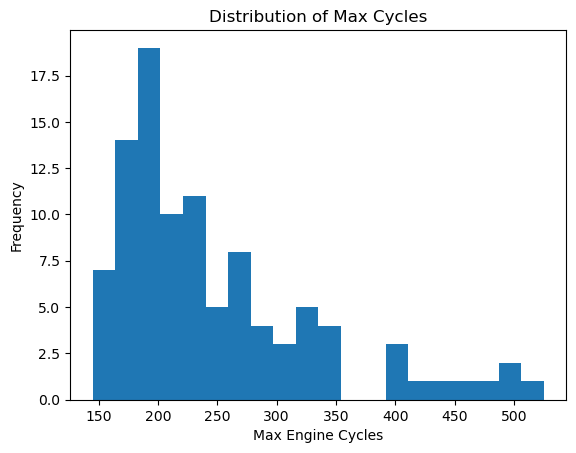

In [9]:
comp01_list = []
comp02_list = []
comp03_list = []
comp04_list = []
for idx in range(1, 101):
    comp01_list.append(comp_engine01_df.loc[comp_engine01_df['engine'] == idx,'cycle'].max())
    comp02_list.append(comp_engine02_df.loc[comp_engine02_df['engine'] == idx,'cycle'].max())
    comp03_list.append(comp_engine03_df.loc[comp_engine03_df['engine'] == idx,'cycle'].max())
    if comp_engine03_df.loc[comp_engine03_df['engine'] == idx,'cycle'].max() == 344:#28, 16
        print(idx)
    comp04_list.append(comp_engine04_df.loc[comp_engine04_df['engine'] == idx,'cycle'].max())
plt.hist(comp03_list, bins=20)
plt.title('Distribution of Max Cycles')
plt.ylabel('Frequency')
plt.xlabel('Max Engine Cycles')
plt.show()

In [10]:

# for i in range(1,10):
#     test_setting = f"setting3"
#     test_sensor = f"sensor{i}"
#     engine_series = comp_engine03_df.loc[comp_engine03_df['engine'] == 69,test_sensor]
#     cycle_series = comp_engine03_df.loc[comp_engine03_df['engine'] == 69,'cycle']
#     engine_series_2 = comp_engine01_df.loc[comp_engine01_df['engine'] == 39,test_sensor]
#     cycle_series_2 = comp_engine01_df.loc[comp_engine01_df['engine'] == 39,'cycle']
#     plt.scatter(cycle_series, engine_series, label="comp_engine03_df")
#     plt.scatter(cycle_series_2, engine_series_2, label="comp_engine01_df")
#     plt.title(f"Engine {1}")
#     plt.xlabel("Cycles")
#     plt.ylabel(f"{sensor_names[test_sensor]}")
#     plt.legend()
#     plt.show()
# sns.pairplot(comp_engine01_df[comp_engine01_df['engine'] == 1])

In [11]:
# Regression Model
# X = comp_engine01_df[comp_engine01_df['engine'] == te].drop(columns=["engine", 'cycle'])
# y = comp_engine01_df[comp_engine01_df['engine'] == te]['cycle']
# te = 3
# me = 5
# X = comp_engine03_df.drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul'])
# y = comp_engine03_df['rul']
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )
X_test_df = test_engine03_df.groupby('engine').last().drop(columns=not_unique_col(test_engine03_df)+['cycle', 'sensor10'])
y_test_df = rul_engine03_df['rul']
X_train_df = comp_engine03_df.drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul']+['cycle', 'sensor10'])
y_train_df = comp_engine03_df['rul']


rfr.fit(X_train_df, y_train_df)
print(f"Random Forest Regressor: {rfr.score(X_test_df, y_test_df)}")
# linreg.fit(X_train_df, y_train_df)
# print(f"Linear Regression: {linreg.score(X_test_df, y_test_df)}")
# dtr.fit(X_train_df, y_train_df)
# print(f"Descision Tree Regressor: {dtr.score(X_test, y_test)}")
xgbr.fit(X_train_df, y_train_df)
print(f"XGB Regressor: {xgbr.score(X_test_df, y_test_df)}")
# ridge_reg.fit(X_train, y_train)
# print(f"Ridge Regressor: {ridge_reg.score(X_test, y_test)}")
# lasso_reg.fit(X_train, y_train)
# print(f"Lasso Regressor: {lasso_reg.score(X_test, y_test)}")

Random Forest Regressor: -0.17467675374895464
XGB Regressor: -0.4400298595428467


In [12]:
# Clip the Data
# X_test_df = test_engine03_df.groupby('engine').last().drop(columns=not_unique_col(test_engine03_df)+['cycle'])
# y_test_df = rul_engine03_df['rul']
# X_train_df = comp_engine03_df.drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul']+['cycle'])
y_train_clipped_df = y_train_df.clip(upper=120)# 112 or 120
rfr.fit(X_train_df, y_train_clipped_df)
# print(f"Random Forest Regressor: {rfr.score(X_test_df, y_test_df)}")
# xgbr.fit(X_train_df, y_train_df)
# print(f"XGB Regressor: {xgbr.score(X_test_df, y_test_df)}")

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['sensor2', 'sensor3',
                                                   'sensor4', 'sensor6',
                                                   'sensor7', 'sensor8',
                                                   'sensor9', 'sensor11',
                                                   'sensor12', 'sensor13',
                                                   'sensor14', 'sensor15',
                                                   'sensor17', 'sensor20',
                                                   'sensor21']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [])])),
                ('regressor', RandomForestRegressor(random_state=42))])

In [14]:
list(sensor_names.keys())[list(sensor_names.values()).index('Fan Inlet Temperature (◦R)')]#['Fan Inlet Temperature (◦R)']
sensor_names['sensor1']

'Fan Inlet Temperature (◦R)'

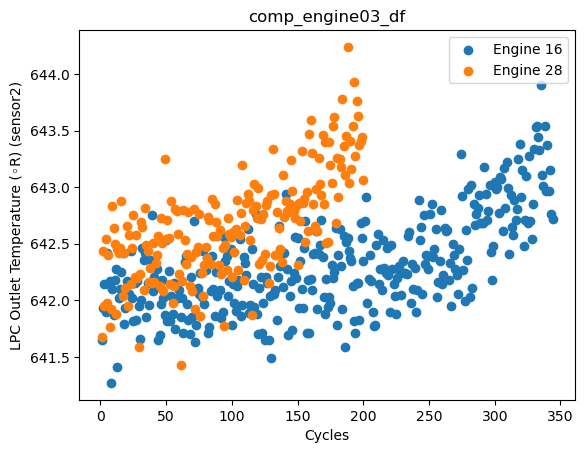

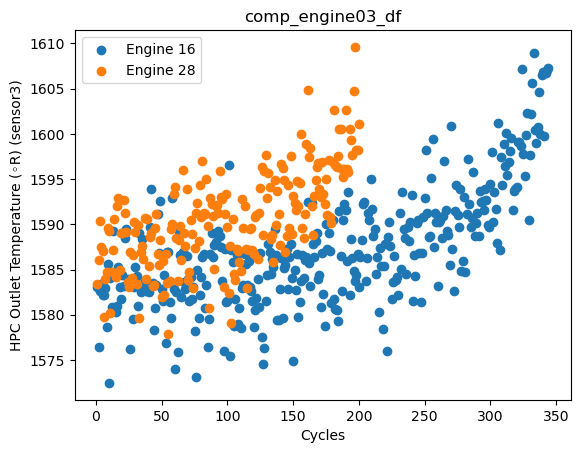

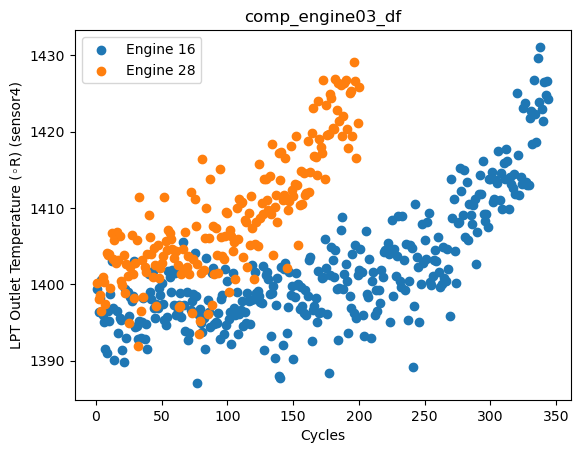

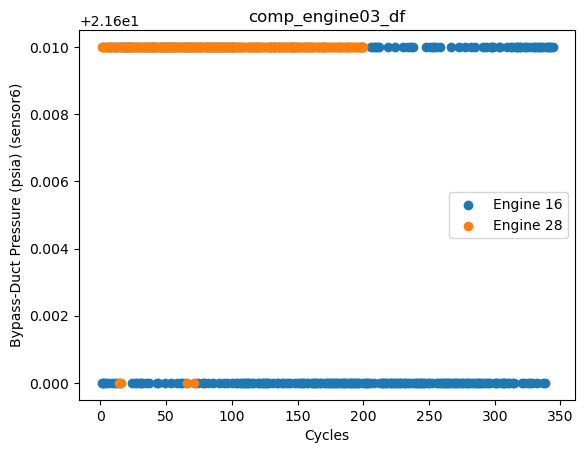

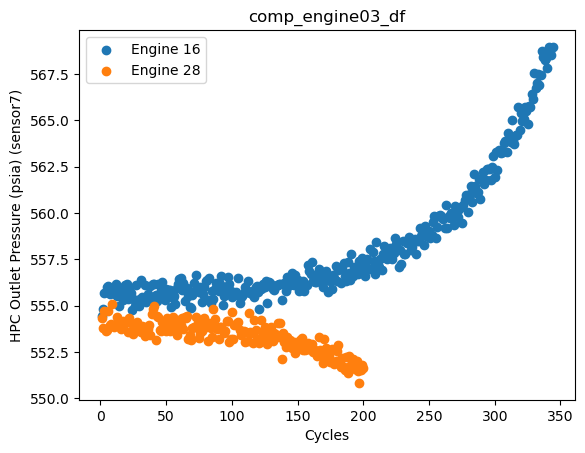

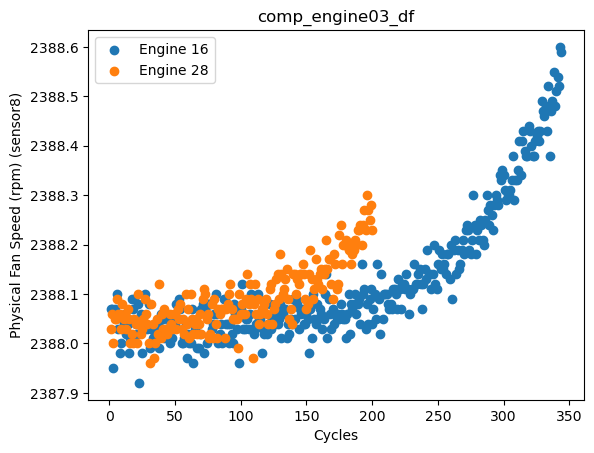

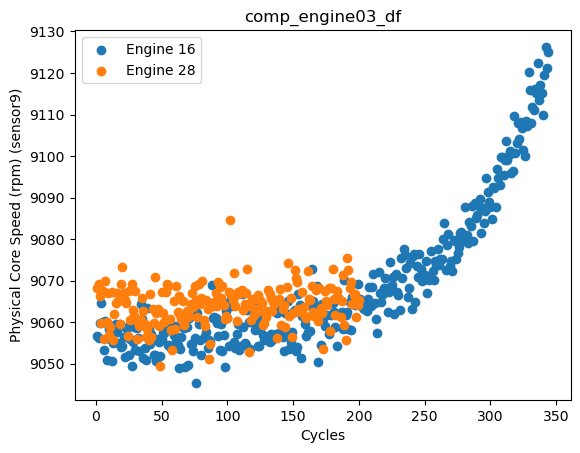

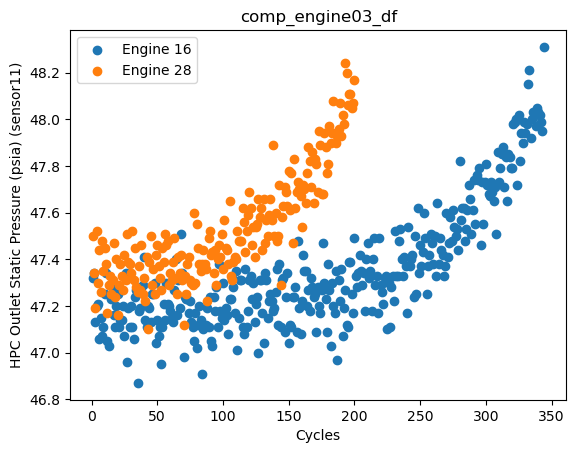

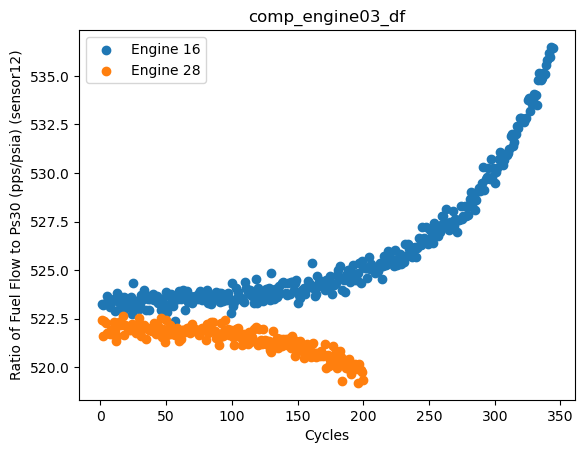

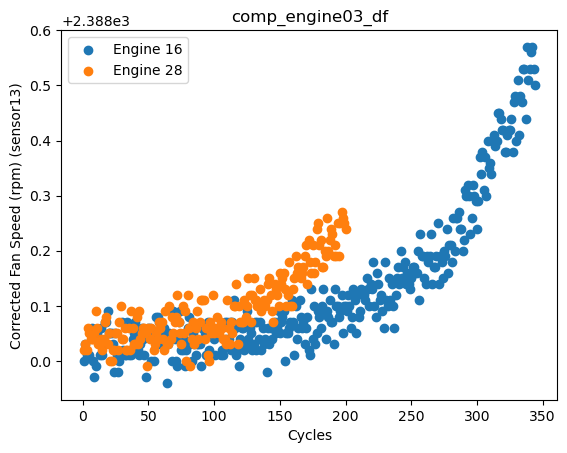

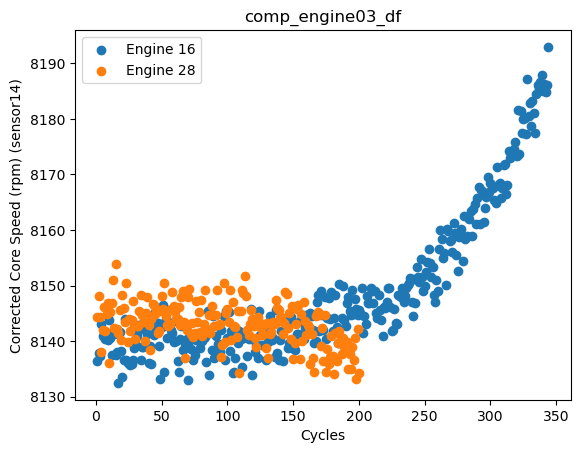

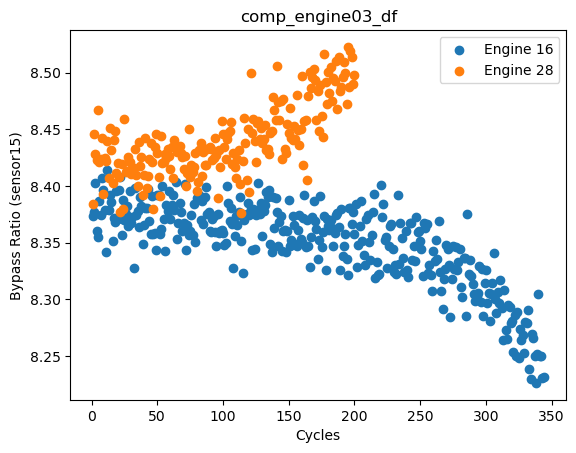

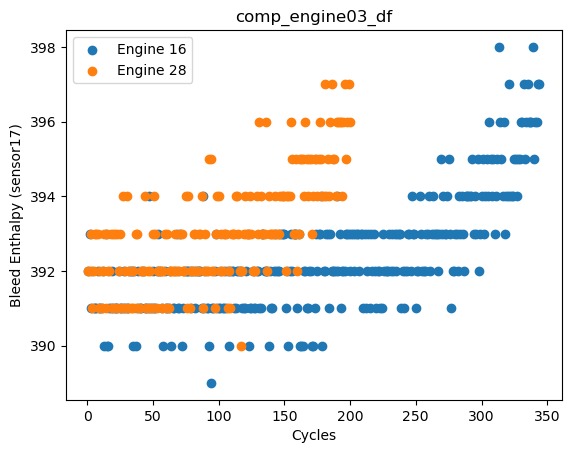

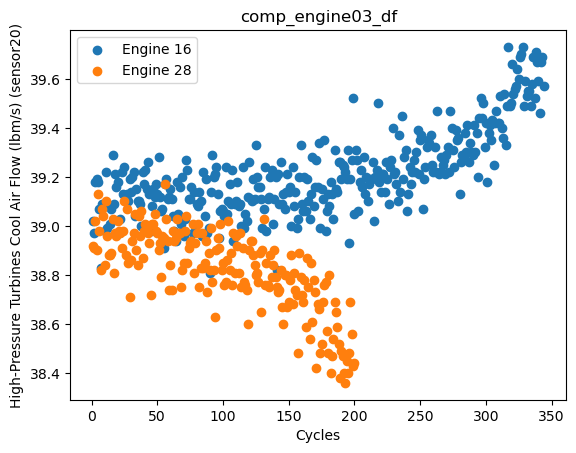

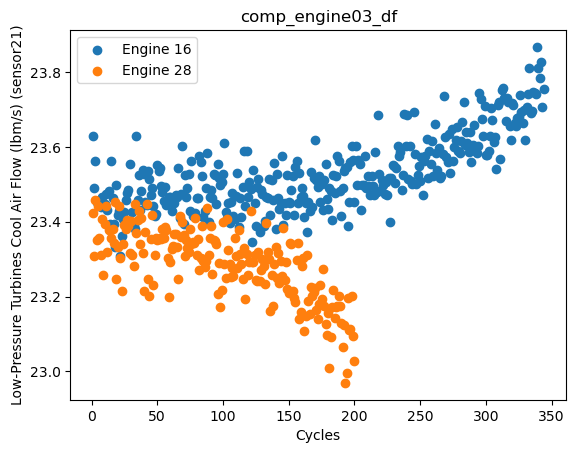

In [15]:
engine_1 = 16
engine_2 = 28
for col in X_train_df.columns:
    engine_series = comp_engine03_df.loc[comp_engine03_df['engine'] == engine_1, col]
    cycle_series = comp_engine03_df.loc[comp_engine03_df['engine'] == engine_1, 'cycle']
    plt.scatter(cycle_series, engine_series, label=f"Engine {engine_1}")
    engine_series_2 = comp_engine03_df.loc[comp_engine03_df['engine'] == engine_2, col]
    cycle_series_2 = comp_engine03_df.loc[comp_engine03_df['engine'] == engine_2, 'cycle']
    plt.scatter(cycle_series_2, engine_series_2, label=f"Engine {engine_2}")
    plt.title(f"comp_engine03_df")
    plt.xlabel("Cycles")
    plt.ylabel(f"{sensor_names[col]} ({col})")
    # plt.gca().invert_xaxis()
    plt.legend()
    plt.show()

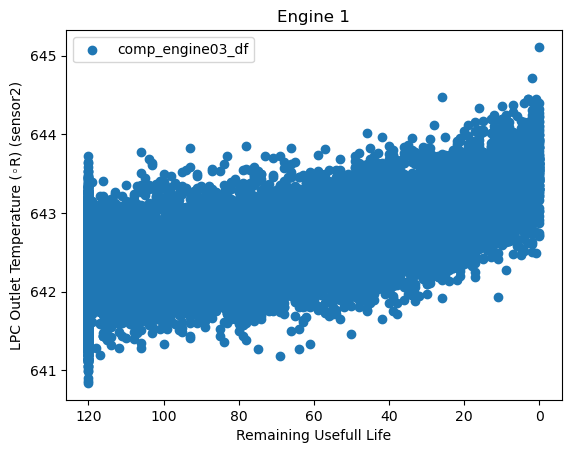

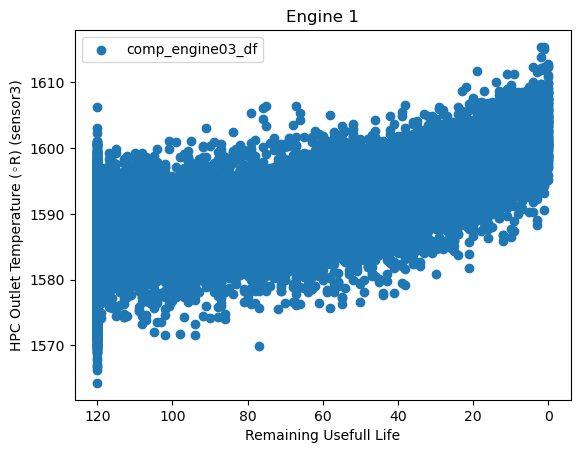

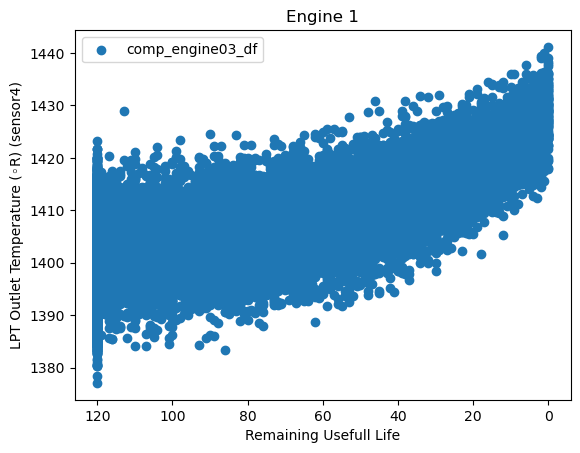

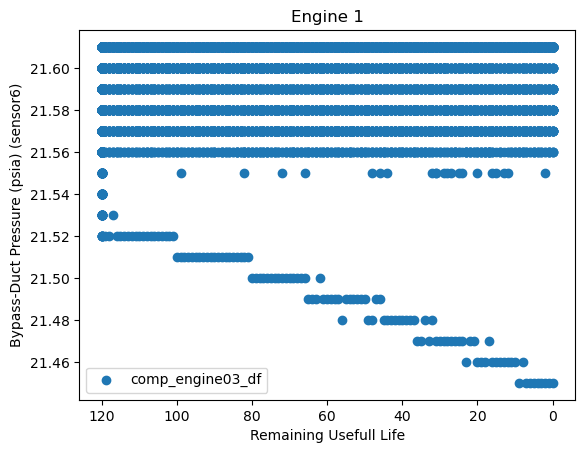

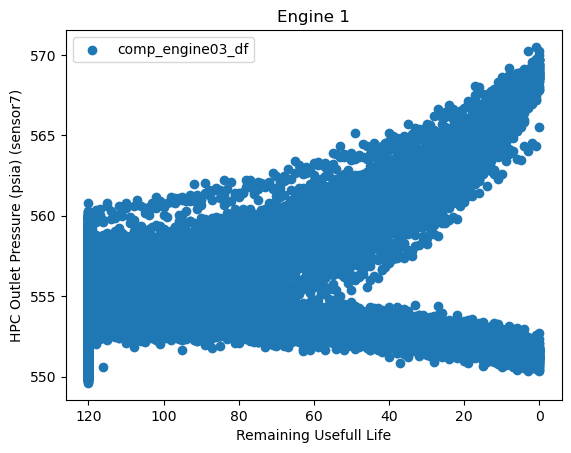

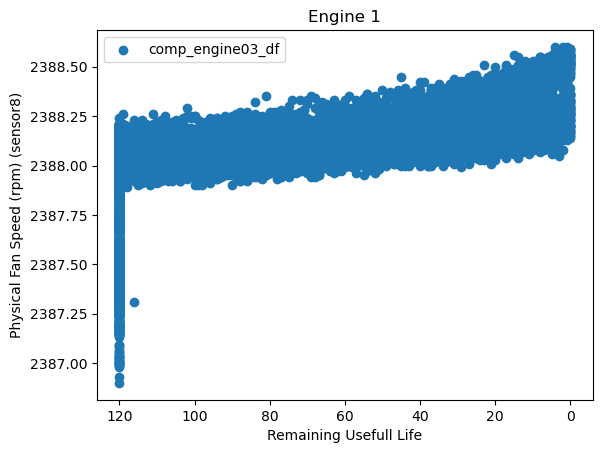

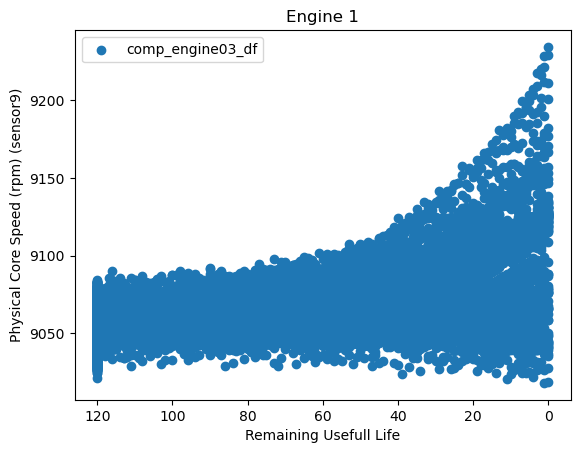

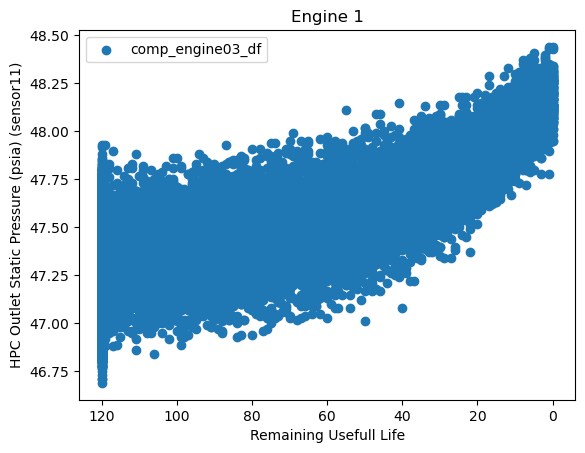

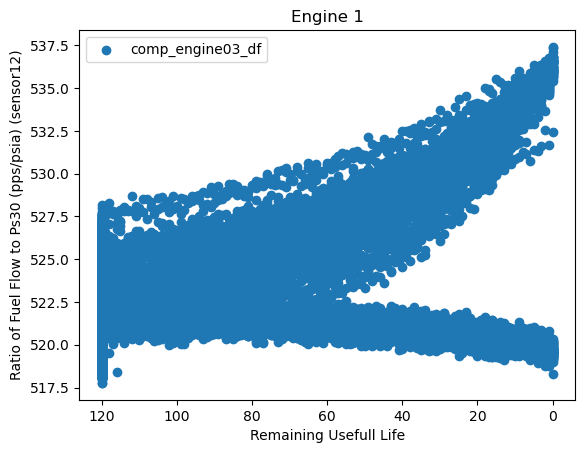

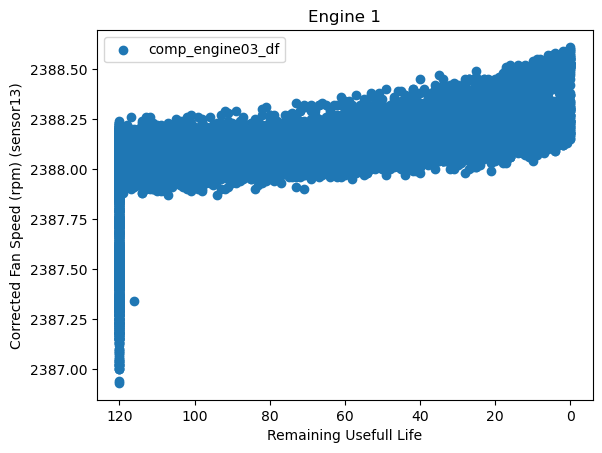

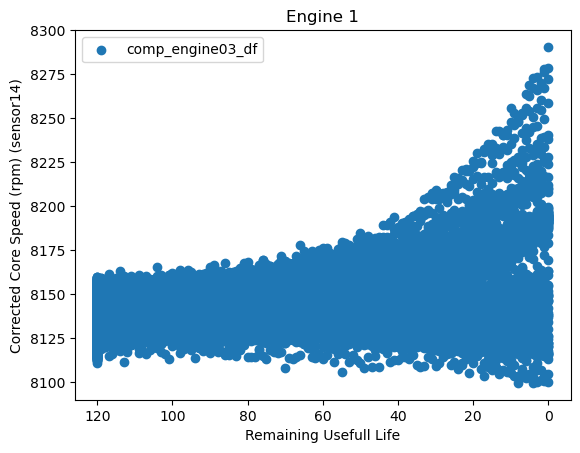

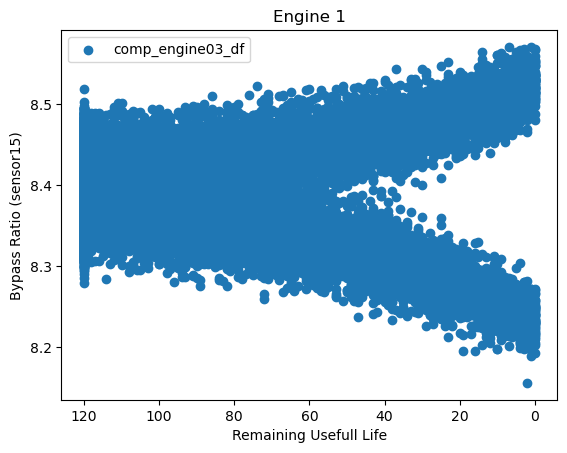

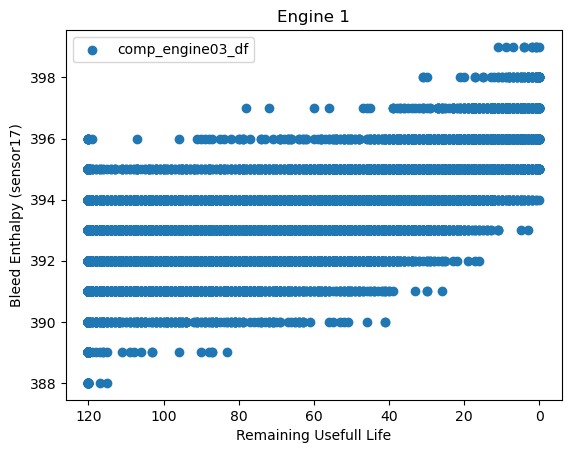

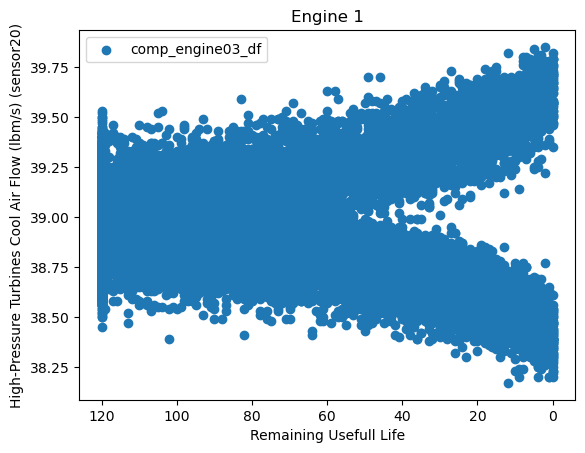

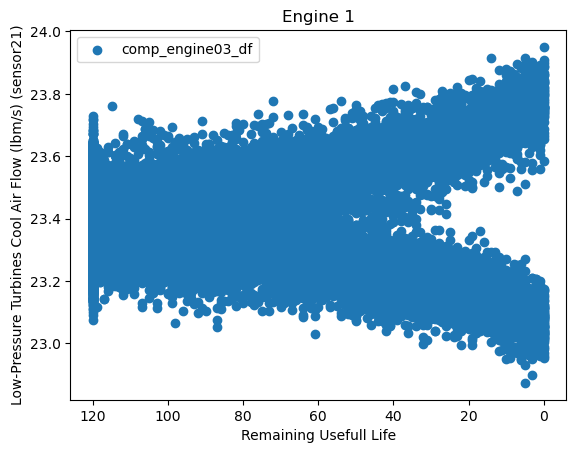

In [16]:
for col in X_train_df.columns:
    engine_series_2 = X_train_df[col]
    cycle_series_2 = y_train_clipped_df
    plt.scatter(cycle_series_2, engine_series_2, label="comp_engine03_df")
    plt.title(f"Engine {1}")
    plt.xlabel("Remaining Usefull Life")
    plt.ylabel(f"{sensor_names[col]} ({col})")
    plt.gca().invert_xaxis()
    plt.legend()
    plt.show()

In [17]:
# # mse for two potential models
# y_pred = rfr.predict(X_test_df)
# mse = mean_squared_error(y_test_df, y_pred)
# print("RFR RMSE:", np.sqrt(mse))
# y_pred = xgbr.predict(X_test_df)
# mse = mean_squared_error(y_test_df, y_pred)
# print("XGBR RMSE:", np.sqrt(mse))

In [18]:
rfr_score_list = []
# linreg_score_list = []
# dtr_score_list = []
# xgbr_score_list = []
# ridge_score_list = []
# lasso_score_list = []
for i in range(1, 101):
    X = comp_engine03_df[comp_engine03_df['engine'] == i].drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul', 'cycle', 'sensor10'])
    y = comp_engine03_df[comp_engine03_df['engine'] == i]['rul']
    rfr_score_list.append(rfr.score(X, y))
    # xgbr_score_list.append(xgbr.score(X,y))
    # for num in range(len(y)):
    #     y_pred = rfr.predict(X.iloc[[num]])
print(f"Average score for Random Forest Regressor: {np.mean(rfr_score_list)}")
# print(f"Average score for XGB Regressor: {np.mean(xgbr_score_list)}")

Average score for Random Forest Regressor: 0.44352777002760246


Random Forest Regressor: 0.738467740034183

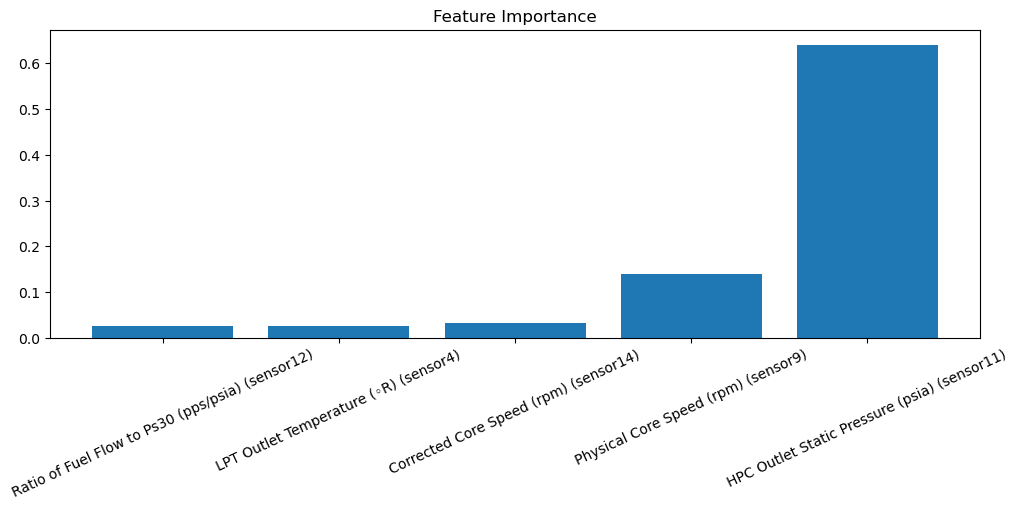

In [19]:
rfr_model = rfr.named_steps["regressor"]
num_fet_name_list = [f"{sensor_names[fet]} ({fet})" for fet in numeric_features]

importances = pd.DataFrame(rfr_model.feature_importances_, columns=["Feature Importance"], index=num_fet_name_list).sort_values(by="Feature Importance", ascending=True).tail()
fig, ax = plt.subplots(figsize=(12,4))
plt.bar(importances.index, importances["Feature Importance"])
plt.title("Feature Importance")
plt.xticks(rotation=25);

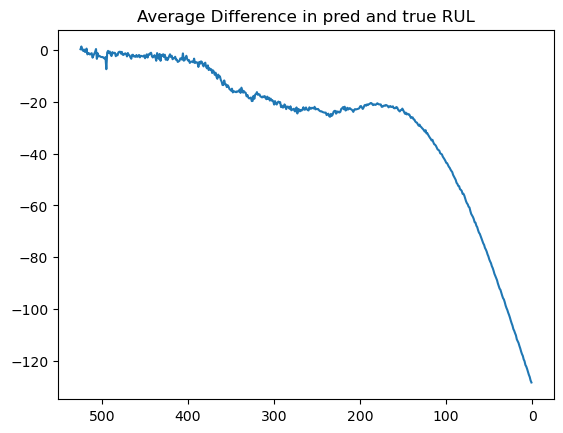

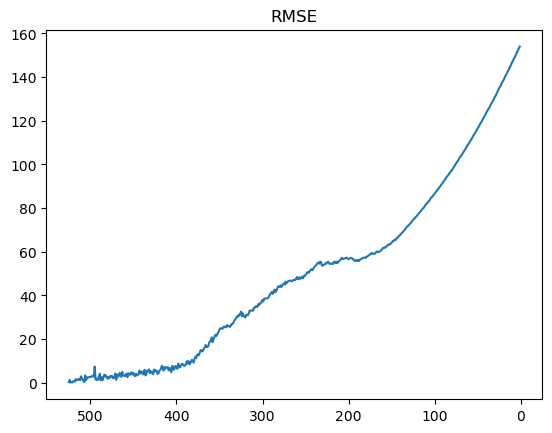

In [21]:
# score based off only sensor data from the first cycle
avg_dif_pred = []
rmse_list = []
for i in range(1, 526):
    X = comp_engine03_df[(comp_engine03_df['cycle'] == i)].drop(columns=not_unique_col(comp_engine03_df)+["engine", 'rul', 'cycle', 'sensor10'])
    y = comp_engine03_df[(comp_engine03_df['cycle'] == i)]['rul']
    y_pred = rfr.predict(X)
    mse = mean_squared_error(y, y_pred)
    rmse_list.append(np.sqrt(mse))
    # print("RMSE:", np.sqrt(mse))
    # print("Score:", rfr.score(X, y))
    # Average prediction was high or low compared to actual
    # print("The Average Difference between pred and true:", np.mean(y_pred - y))
    avg_dif_pred.append(np.mean(y_pred - y))
plt.plot(range(1, 526), avg_dif_pred)
plt.title('Average Difference in pred and true RUL')
plt.gca().invert_xaxis()
plt.show()
plt.plot(range(1, 526), rmse_list)
plt.title('RMSE')
plt.gca().invert_xaxis()
plt.show()

Mechanic and scheduling maintence section / supply can schedule things to prevent greater periods of downtime and 
abstract turns translates into the real world.

Identify when something isn't right. No reports. Helps decide where to focus attention. This will show where common boat routes are. Color shows frequency. Removes all high frequency data. 
What diod you actually find?
It can take a while to load.
The changing of perspective can be very jaring.
What can we actually learn from your model? Could we see the track of the vessel and why OLAF picked up on it?
Make sure your camera and screen are in the same loactions.

Mention how the line in categorizing Potential Failures is important. This was the closest I felt comfortable getting based on the error within my model. Make sure to explain why you are showing the differences in HPC Outlet Pressure. 

In [22]:
pred_df = pd.DataFrame(columns=['engine', 'rul' , 'label'])
pred_df.loc[len(pred_df), 'engine'] = 1
pred_df.loc[len(pred_df), 'rul'] = 1739
pred_df.loc[len(pred_df), 'label'] = "good"
pred_df

,engine,rul,label
0,1,NaN,NaN
1,NaN,1739,NaN
2,NaN,NaN,good


In [23]:
# score based off only sensor data from the last cycle
# X_test_df = test_engine03_df.groupby('engine').last().drop(columns=not_unique_col(test_engine03_df)+["cycle"])
# y_test_df = rul_engine03_df['rul']
y_pred = rfr.predict(X_test_df)
mse = mean_squared_error(y_test_df, y_pred)
rfr_model_score = rfr.score(X_test_df, y_test_df)
print("RMSE:", np.sqrt(mse))
print("R^2 Score:", rfr_model_score)
# Average prediction was high or low compared to actual
print("The Average Difference between pred and true:", np.mean(y_pred - y_test_df))

RMSE: 20.678383157297382
R^2 Score: 0.7504691124684115
The Average Difference between pred and true: 3.8157999999999994


In [24]:
rfr_model

RandomForestRegressor(random_state=42)

In [25]:
metadata = {
    "model_name": "RandomForestRegressor",
    "date_trained": datetime.datetime.now().strftime("%Y-%m-%d %H:%M"),
    "features_used": list(X_train_df.columns),
    "r_squared_score" : rfr_model_score,
    "notes": "Random forest with optimal values chosen with gridsearchcv"
}

model_package = {
    "model": rfr,
    "metadata": metadata
}

# with open("base_model.pkl", "wb") as f:
#     pickle.dump(model_package, f)

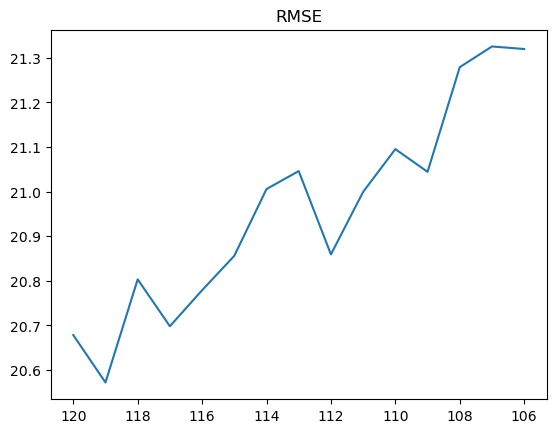

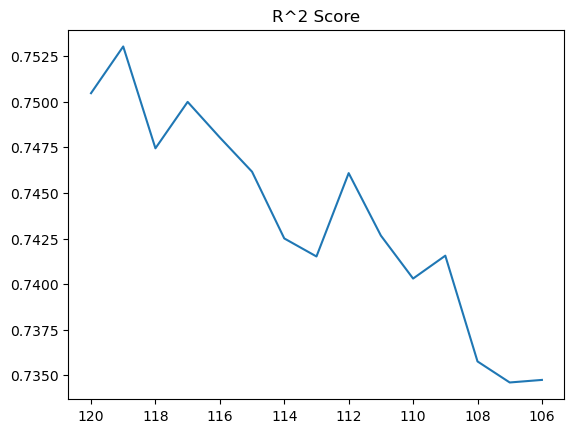

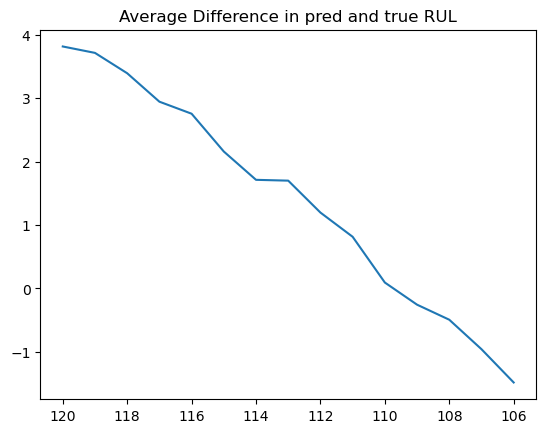

In [26]:
# Testing for what clipping effect had on data
rmse_test_list = []
score_test_list = []
avg_test_list =[]
min_range = 106
max_range = 121
for i in range(min_range, max_range):
    y_train_clipped_df = y_train_df.clip(upper=i)
    rfr.fit(X_train_df, y_train_clipped_df)
    y_pred = rfr.predict(X_test_df)
    mse = mean_squared_error(y_test_df, y_pred)
    rmse_test_list.append(np.sqrt(mse))
    score_test_list.append(rfr.score(X_test_df, y_test_df))
    # Average prediction was high or low compared to actual
    avg_test_list.append(np.mean(y_pred - y_test_df))
plt.plot(range(min_range, max_range), rmse_test_list)
plt.title('RMSE')
plt.gca().invert_xaxis()
plt.show()
plt.plot(range(min_range, max_range), score_test_list)
plt.title('R^2 Score')
plt.gca().invert_xaxis()
plt.show()
plt.plot(range(min_range, max_range), avg_test_list)
plt.title('Average Difference in pred and true RUL')
plt.gca().invert_xaxis()
plt.show()

* Average score for Random Forest Regressor: 0.49154279252979227
* RMSE: 21.16981466617032
* Score: 0.738467740034183
* The Average Difference between pred and true: 5.5519

In [27]:
# # attempt at finding better potential values
# param_grid = {
#     "regressor__n_estimators": [100, 150, 200],
#     "regressor__max_depth": [None, 5, 10]
# }

# grid_search = GridSearchCV(rfr, param_grid, cv=3, n_jobs=-1)
# grid_search.fit(X_train_df, y_train_df)

In [28]:
# print("\n--- BEST PARAMETERS AFTER GRID SEARCH ---")
# print(grid_search.best_params_)

# best_model = grid_search.best_estimator_
# y_pred_best = best_model.predict(X_test_df)
# mse = mean_squared_error(y_test_df, y_pred_best)
# print("RMSE:", np.sqrt(mse))
# print("Score:", best_model.score(X_test_df, y_test_df))